In [1]:
# Load necessary library
library(fs)
library("ggplot2")
install.packages("tidyverse")
library(dplyr)
library("tidyverse")
# Required library for rolling mean
library(zoo)  # Install if needed: install.packages("zoo")
# Assuming 'dot_plot_data' is wide format, create a heatmap (for a grid of values)

library(RColorBrewer)


Updating HTML index of packages in '.Library'

Making 'packages.html' ...
 done


Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union


── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ forcats   1.0.0     ✔ stringr   1.5.0
✔ lubridate 1.9.3     ✔ tibble    3.3.1
✔ purrr     1.0.2     ✔ tidyr     1.3.0
✔ readr     2.2.0     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors

Attaching package: ‘zoo’


The following objects are masked from ‘package:base’:

    as.Date, as.Date.numeric




load fixed r files

In [3]:
# Fixed r setting
filepath_newhetfile_smbc_new_regions <- paste0("/home/usriniva/Desktop/masters/Plasmodium_us_scripts/binh_out/smbc/fixed_r/mut_rate_4.0425e-09")
plot_data_list_newhetfile_smbc_fixed_r <- list()  # Fixed: was full_chr_fixed_r

for (i in 9:14) {
    chr <- sprintf("%02d", i)
    
    file_pattern <- paste0("BinhPhuoc_chr", chr, "_top4_individuals_region_.*\\.mhs\\.rds$")
    matching_files <- list.files(filepath_newhetfile_smbc_new_regions, pattern = file_pattern, full.names = TRUE)
    
    if (length(matching_files) > 0) {
        maesot_smbc_fixed_r <- readRDS(matching_files[1])
        plot_data_list_newhetfile_smbc_fixed_r[[chr]] <- maesot_smbc_fixed_r  # Fixed: matches list name
        cat("Loaded chr", chr, ":", basename(matching_files[1]), "\n")
    } else {
        cat("No files found for chr", chr, "in", filepath_newhetfile_smbc_new_regions, "\n")
    }
}

# Free r setting
filepath_newhetfile_smbc_new_regions_free <- paste0("/home/usriniva/Desktop/masters/Plasmodium_us_scripts/binh_out/smbc/free_r/mut_rate_4.0425e-09/mut_rate_4.0425e-09")  # Fixed: added /top4
plot_data_list_newhetfile_smbc_free_r <- list()

for (i in 9:14) {
    chr <- sprintf("%02d", i)
    
    file_pattern <- paste0("BinhPhuoc_chr", chr, "_top4_individuals_region_.*\\.mhs\\.rds$")
    matching_files <- list.files(filepath_newhetfile_smbc_new_regions_free, pattern = file_pattern, full.names = TRUE)
    
    if (length(matching_files) > 0) {
        maesot_smbc_free_r <- readRDS(matching_files[1])  # Fixed: variable name
        plot_data_list_newhetfile_smbc_free_r[[chr]] <- maesot_smbc_free_r  # Fixed: matches list name + variable
        cat("Loaded chr", chr, ":", basename(matching_files[1]), "\n")
    } else {
        cat("No files found for chr", chr, "in", filepath_newhetfile_smbc_new_regions_free, "\n")
    }
}


Loaded chr 09 : BinhPhuoc_chr09_top4_individuals_region_79101-1242137,1244484-1473560.mhs.rds 
Loaded chr 10 : BinhPhuoc_chr10_top4_individuals_region_68971-1389098,1399594-1571815.mhs.rds 
Loaded chr 11 : BinhPhuoc_chr11_top4_individuals_region_110001-831968,834246-1009859,1021025-1294107,1295621-2003320.mhs.rds 
Loaded chr 12 : BinhPhuoc_chr12_top4_individuals_region_60301-766654,780451-1282773,1285068-1688600,1745531-2163700.mhs.rds 
Loaded chr 13 : BinhPhuoc_chr13_top4_individuals_region_74414-74436,106668-1168127,1170426-1361761,1466920-2791900.mhs.rds 
Loaded chr 14 : BinhPhuoc_chr14_top4_individuals_region_35775-1071523,1075090-3118071,3126627-3255710.mhs.rds 
Loaded chr 09 : BinhPhuoc_chr09_top4_individuals_region_79101-1242137,1244484-1473560.mhs.rds 
Loaded chr 10 : BinhPhuoc_chr10_top4_individuals_region_68971-1389098,1399594-1571815.mhs.rds 
Loaded chr 11 : BinhPhuoc_chr11_top4_individuals_region_110001-831968,834246-1009859,1021025-1294107,1295621-2003320.mhs.rds 
Loaded c

load full chromosome data

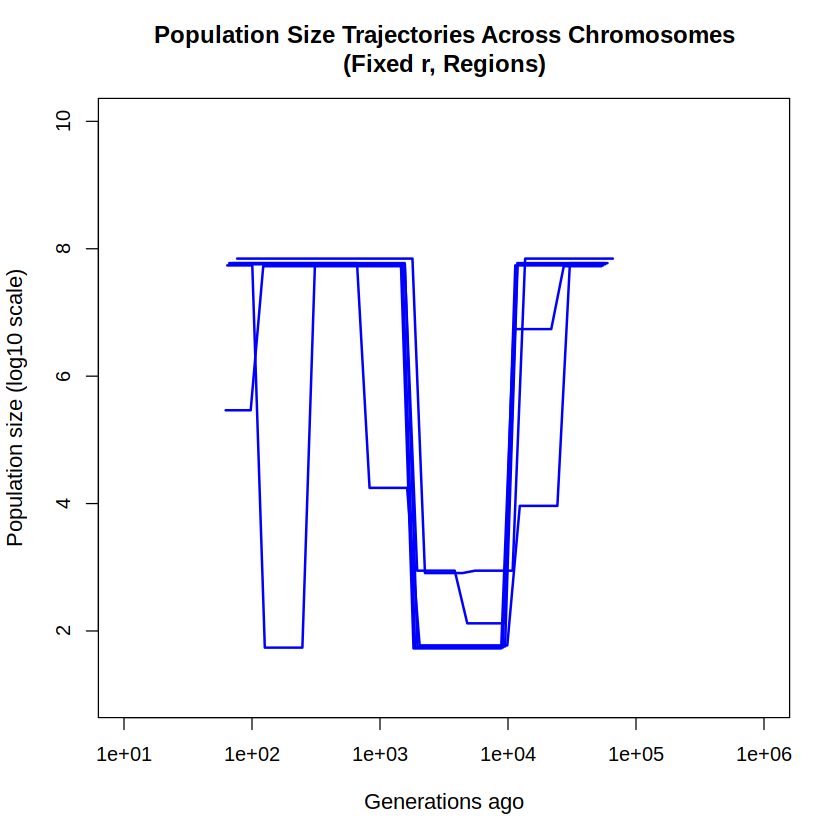

In [4]:
# Set mutation rate and generation time
mu <- 4.0425e-09
gen <- 0.16

par(bg = "white", mfrow = c(1, 1))  # Clean plot setup

# Set up main plot with proper limits and labels
plot(c(10, 10^6), c(1, 10), 
     log = "x", type = "n", 
     xlab = "Generations ago", 
     ylab = "Population size (log10 scale)", 
     main = "Population Size Trajectories Across Chromosomes\n(Fixed r, Regions)",
     cex.lab = 1.1, cex.main = 1.2)



# 2. Plot main thick lines for full chromosomes (from your fixed_r list + others)
main_chrs <- names(plot_data_list_newhetfile_smbc_fixed_r)
for (chr in main_chrs) {
  # Fixed r full chr (red thick line)
  if (!is.null(plot_data_list_newhetfile_smbc_fixed_r[[chr]])) {
    data <- plot_data_list_newhetfile_smbc_fixed_r[[chr]]
    Tc <- data$Tc * gen
    Ne_t <- data$Xi
    Ne_scale <- mean(data$mu / mu)
    lines(Tc * Ne_scale, log10(Ne_t * Ne_scale), 
          col = 'blue', lwd = 2)
  }
  
  # Add other data types here when available (free_r_fullchr, wprior_fullchr)
  # Follow same pattern with their respective data lists
}

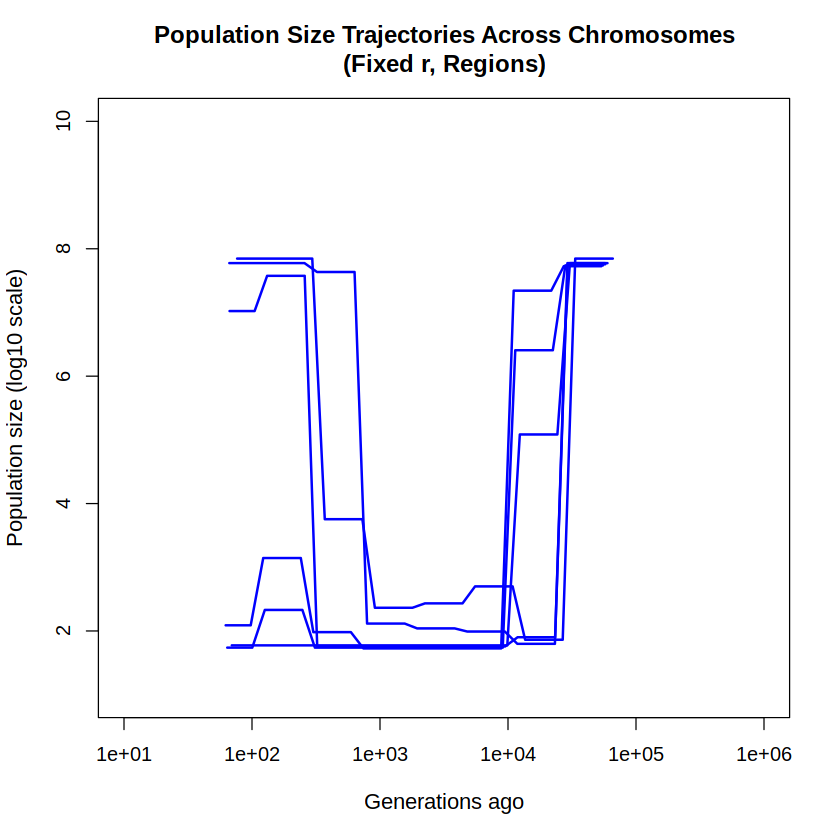

In [5]:


# Set mutation rate and generation time
mu <- 4.0425e-09
gen <- 0.16

par(bg = "white", mfrow = c(1, 1))  # Clean plot setup

# Set up main plot with proper limits and labels
plot(c(10, 10^6), c(1, 10), 
     log = "x", type = "n", 
     xlab = "Generations ago", 
     ylab = "Population size (log10 scale)", 
     main = "Population Size Trajectories Across Chromosomes\n(Fixed r, Regions)",
     cex.lab = 1.1, cex.main = 1.2)




# 2. Plot main thick lines for full chromosomes (from your fixed_r list + others)
main_chrs <- names(plot_data_list_newhetfile_smbc_free_r)
for (chr in main_chrs) {
  # Fixed r full chr (red thick line)
  if (!is.null(plot_data_list_newhetfile_smbc_free_r[[chr]])) {
    data <- plot_data_list_newhetfile_smbc_free_r[[chr]]
    Tc <- data$Tc * gen
    Ne_t <- data$Xi
    Ne_scale <- mean(data$mu / mu)
    lines(Tc * Ne_scale, log10(Ne_t * Ne_scale), 
          col = 'blue', lwd = 2)
  }
  
  # Add other data types here when available (free_r_fullchr, wprior_fullchr)
  # Follow same pattern with their respective data lists
}


In [6]:
# Initialize empty vectors for alpha and rho/mu values
rho_values <- c()
alpha_values <- c()
rho_mu_ratios <- c()
chromosomes <- c()  # To store valid chromosome names
category_labels <- c()  # To store categories (e.g., Free_r Regions, Free_r Full)

for (chr in names(plot_data_list_newhetfile_smbc_fixed_r)) {
    if (length(plot_data_list_newhetfile_smbc_fixed_r[[chr]]) > 0) {  # Ensure the object is not empty
        chr_data <- plot_data_list_newhetfile_smbc_fixed_r[[chr]]
        if (!is.null(chr_data$rho) && !is.null(chr_data$alpha) && 
            length(chr_data$rho) > 0 && length(chr_data$alpha) > 0) {
            # Append data to the vectors

            rho_values <- c(rho_values, chr_data$rho)
            alpha_values <- c(alpha_values, chr_data$alpha)
            rho_mu_ratios <- c(rho_mu_ratios, chr_data$rho / chr_data$mu)
            chromosomes <- c(chromosomes, chr)  # Add chromosome name
            category_labels <- c(category_labels, rep("Fixed r subset Regions", length(chr_data$rho)))
        }
    }
}


# Create a data frame for plotting
boxplot_data <- data.frame(
    chromosomes=chromosomes,
    Rho = rho_values,
    Alpha = alpha_values,
    Rho_Mu_Ratio = rho_mu_ratios,
    Category = category_labels
)

boxplot_data


chromosomes,Rho,Alpha,Rho_Mu_Ratio,Category
<chr>,<dbl>,<dbl>,<dbl>,<chr>
09,0.002406705,1.20,10,Fixed r subset Regions
10,0.002831973,1.25,10,Fixed r subset Regions
11,0.002401677,1.10,10,Fixed r subset Regions
12,0.002212774,1.10,10,Fixed r subset Regions
13,0.002306849,1.10,10,Fixed r subset Regions
14,0.002150768,1.10,10,Fixed r subset Regions


#### Free r

In [7]:
# Initialize empty vectors for alpha and rho/mu values
rho_values <- c()
alpha_values <- c()
rho_mu_ratios <- c()
chromosomes <- c()  # To store valid chromosome names
category_labels <- c()  # To store categories (e.g., Free_r Regions, Free_r Full)

for (chr in names(plot_data_list_newhetfile_smbc_free_r)) {
    if (length(plot_data_list_newhetfile_smbc_free_r[[chr]]) > 0) {  # Ensure the object is not empty
        chr_data <- plot_data_list_newhetfile_smbc_free_r[[chr]]
        if (!is.null(chr_data$rho) && !is.null(chr_data$alpha) && 
            length(chr_data$rho) > 0 && length(chr_data$alpha) > 0) {
            # Append data to the vectors

            rho_values <- c(rho_values, chr_data$rho)
            alpha_values <- c(alpha_values, chr_data$alpha)
            rho_mu_ratios <- c(rho_mu_ratios, chr_data$rho / chr_data$mu)
            chromosomes <- c(chromosomes, chr)  # Add chromosome name
            category_labels <- c(category_labels, rep("Free r subset Regions", length(chr_data$rho)))
        }
    }
}


# Create a data frame for plotting
boxplot_data <- data.frame(
    chromosomes=chromosomes,
    Rho = rho_values,
    Alpha = alpha_values,
    Rho_Mu_Ratio = rho_mu_ratios,
    Category = category_labels
)

boxplot_data


chromosomes,Rho,Alpha,Rho_Mu_Ratio,Category
<chr>,<dbl>,<dbl>,<dbl>,<chr>
09,0.02406705,1.20,100,Free r subset Regions
10,0.02831973,1.25,100,Free r subset Regions
11,0.02401677,1.10,100,Free r subset Regions
12,0.02212774,1.10,100,Free r subset Regions
13,0.02306849,1.10,100,Free r subset Regions
14,0.02150768,1.10,100,Free r subset Regions


In [9]:
# Write the data frame to CSV
write.csv(boxplot_data, "/home/usriniva/Desktop/masters/plasmodium/Final_analysis/5_SMC_run_visualization/1_Final_alphas/Core_regions_high_recomb _removed_dataset/hi_recomb_removed_free_r_ncv", row.names = FALSE)